In [2]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# **Persamaan Parabolik**

Persamaan Parabolik
Sekarang akhirnya kita beralih untuk menggabungkan apa yang telah kita pelajari tentang diskretisasi spasial dengan masalah nilai batas bersama diskretisasi temporal untuk masalah nilai awal.  Jenis persamaan pertama yang akan kita pelajari adalah persamaan parabolik, yang untuknya persamaan panas

$$
    u_t = \kappa u_{xx}
$$

akan menjadi fokus kita.  Banyak sifat umum dari metode numerik yang akan kita turunkan untuk persamaan panas juga akan berlaku untuk banyak persamaan parabolik lainnya.
Bersama dengan persamaan di atas kita juga memerlukan syarat batas

$$\begin{aligned}
    u(0, t) &= g_0(t) \quad \text{untuk} \quad &t > 0 & \text{   dan} \\
    u(1, t) &= g_1(t) \quad \text{untuk} \quad &t > 0 &
\end{aligned}$$

bersama dengan syarat awal
$$
    u(x, 0) = u_0(x).
$$

Di sini kita telah mengasumsikan bahwa domain kita $\Omega = [0, 1]$, $t_0 = 0$, dan bahwa kita memiliki syarat batas Dirichlet (kita akan melihat implementasi lain nanti).
Kita juga akan mendiskretisasi domain ruang-waktu sedemikian sehingga
$$
    x_i = i \Delta x \quad \quad t_n = n \Delta t
$$
dan bahwa diskretisasi numerik kita $U$ akan mendekati fungsi sebenarnya $u$ pada titik $(x_i, t_n)$ sedemikian sehingga
$$
    U^n_i \approx u(x_i, t_n).
$$
Sebagai upaya pertama untuk mendiskretisasi persamaan panas mari kita gunakan Euler maju untuk mendiskretisasi dalam waktu dan beda terpusat orde 2 dalam ruang untuk memperoleh
$$
    \frac{U^{n+1}_i - U^n_i}{\Delta t} = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$
atau dalam bentuk pembaruan
$$
    U^{n+1}_i = U^n_i + \frac{\Delta t}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1}).
$$
Salah satu cara untuk melihat diskretisasi ini adalah dengan menganggapnya lagi sebagai masalah nilai awal sehingga
$$
    U^{n+1}_i = U^n_i + \Delta t f(t_n, U^n_i)
$$

di mana sekarang diskretisasi spasial termuat di dalam $f$ sehingga dalam kasus di atas kita memiliki
$$
    f(t_n, U^n_i) = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$
yang memberi kita sarana untuk menganalisis metode ini dalam konteks metode numerik masalah nilai awal.
Metode lain yang juga hanya menggunakan satu langkah tetapi lebih praktis seperti yang akan kita lihat disebut metode *Crank-Nicholson*.  Metode ini didasarkan pada diskretisasi metode trapesium sedemikian sehingga
$$\begin{aligned}
    \frac{U^{n+1}_i - U^n_i}{\Delta t} &= \frac{1}{2} (f(U^n_i) + f(U^{n+1}_i)) \\
    &= \frac{1}{2} \frac{U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1}}{\Delta x^2} \Rightarrow \\
    U^{n+1}_i &= U^n_i + \frac{\Delta t}{2 \Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1})
\end{aligned}$$

Cobalah menggambar stencil dari metode ini.
Dari rumus pembaruan kita dapat melakukan sedikit aljabar untuk memperoleh
$$
    -r U^{n+1}_{i-1} + (1 + 2r) U^{n+1}_i - r U^{n+1}_{i+1} = r U^{n}_{i-1} + (1 - 2r) U^{n}_{i} + r U^{n}_{i+1}
$$
di mana $r = \frac{\Delta t}{2 \Delta x^2}$.

Cobalah menuliskan sistem persamaan untuk ini jika kita memiliki $m=5$.
Ini membentuk sistem persamaan tridiagonal berbentuk $A U^{n+1} = f(t_n, U^n)$ di mana
$$
    A = \begin{bmatrix}
        1+2r & -r \\
        -r & 1+2r & -r \\
        & -r & 1+2r & -r \\
        & & \ddots & \ddots & \ddots \\
        & & & -r & 1+2r & -r \\
        & & & & -r & 1+2r
    \end{bmatrix}
$$
$$
    f(t_n, U^{n}) = \begin{bmatrix}
        r (g_0(t_n) + g_0(t_{n+1})) + (1 - 2r) U^n_1 + r U^n_2 \\
        r U^n_1 + (1-2r) U^n_2 + r U^n_3 \\
        r U^n_2 + (1-2r) U^n_3 + r U^n_4 \\
        \vdots \\
        r U^n_{m-2} + (1-2r) U^n_{m-1} + r U^n_m \\
        r U^n_{m-1} + (1-2r) U^n_m + r(g_1(t_n) + g_1(t_{n+1}))
    \end{bmatrix}
$$

Dari pembahasan kita tentang metode iteratif, kita mungkin dapat menyelesaikan ini dalam $\mathcal{O}(m)$ langkah sehingga metode Crank-Nicholson untuk persamaan panas seefisien metode eksplisit kita di atas.  Keuntungan metode implisit adalah bahwa ia memungkinkan langkah waktu yang jauh lebih besar daripada metode eksplisit karena kendala stabilitas yang akan kita bahas secara rinci (persamaan panas dapat dianggap sebagai sistem ODE yang kaku).
## **Kesalahan Trunkasi Lokal**
Galat trunkasi lokal $\tau^n$ sekali lagi dihitung sama seperti sebelumnya kecuali sekarang kita perlu menangani baik turunan temporal maupun spasial.  Kita tetap akan mengikuti prosedur yang sama seperti sebelumnya, memasukkan solusi sebenarnya $u(x,t)$ ke dalam diskretisasi yang sesuai dan menggunakan ekspansi Taylor untuk menemukan suku galat dominan.        
Sebagai contoh pertimbangkan metode eksplisit yang dikembangkan di atas.  Sekarang kita memiliki
$$
    \tau^n_i = \tau(x_i, t_n) = \frac{u(x, t + \Delta t) - u(x, t)}{\Delta t} - \frac{1}{\Delta x^2} (u(x - \Delta x, t) - 2 u(x, t) + u(x + \Delta x, t))
$$
Ekspansi Taylor yang relevan adalah
$$\begin{aligned}
    u(x, t + \Delta t) &= u(x,t) + u_t(x,t) \Delta t + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4) \\
    u(x \pm \Delta x, t) &= u(x,t) \pm \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) \pm \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5).
\end{aligned}$$
Ini menghasilkan galat trunkasi sebesar
$$\begin{aligned}
    \tau(x,t) &= \frac{1}{\Delta t} \left(u(x,t) + u_t(x,t) \Delta t + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4) - u(x,t) \right ) \\
    & \quad - \frac{1}{\Delta x^2} \left (u(x,t) - \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) - \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) \right .\\
    & \quad - 2 u(x,t) \\
    & \quad \left .+ u(x,t) + \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) + \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5)\right ) \\
    &= u_t(x,t)+ \frac{\Delta t}{2} u_{tt}(x,t) + \frac{\Delta t^2}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^3)  - u_{xx}(x,t) - \frac{\Delta x^2}{24} u_{xxxx}(x,t) - \frac{\Delta x^2}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5) \\
    &=  \frac{\Delta t}{2} u_{tt}(x,t) + \frac{\Delta t^2}{6} u_{ttt}(x,t) - \frac{\Delta x^2}{12} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^4, \Delta t^2)
\end{aligned}$$

Agar ekspresi kita untuk galat trunkasi lebih sederhana, kita dapat mendiferensiasikan solusi sebenarnya melalui
$$
    (u_t)_t = (u_{xx})_t \rightarrow u_{tt} = (u_t)_{xx} = u_{xxxx}
$$
dengan asumsi solusi cukup mulus sehingga kita dapat mengganti turunan temporal dalam galat trunkasi kita untuk memperoleh
$$\begin{aligned}
    \tau(x,t) &= \left ( \frac{\Delta t}{2} - \frac{\Delta x^2}{12} \right) u_{xxxx} + \mathcal{O}(\Delta t^2, \Delta x^4)
\end{aligned}$$
yang membawa kita pada kesimpulan bahwa metode ini berorde satu dalam waktu dan berorde dua dalam ruang.  Dengan demikian kita melihat bahwa metode eksplisit di atas setidaknya konsisten.
Kita juga dapat menunjukkan bahwa metode Crank-Nicholson berorde dua baik dalam waktu maupun ruang, yaitu
$$
    \tau(x,t) = \mathcal{O}(\Delta t^2, \Delta x^2).
$$

## Metode Garis
*Method of lines* mengacu pada pendiskretisasian komponen spasial dan temporal dari suatu PDE secara terpisah.  Ini berguna untuk menganalisis metode serta sebagai cara langsung untuk memastikan galat trunkasi tertentu.  Di atas kita telah menggunakan pendekatan ini pada persamaan panas dengan mendiskretisasi turunan spasial menggunakan aproksimasi terpusat orde dua terhadap turunan kedua yang menghasilkan suatu sistem ODE, yang sering disebut *metode semi-diskret*.
Melihat kembali contoh-contoh kita, pendekatan method of lines akan memberi kita sistem
$$
    U_i'(t) = \frac{1}{\Delta x^2} (U_{i-1}(t) - 2 U_i(t) + U_{i+1}(t))
$$
yang dapat kita terapkan metode IVP apa pun padanya (dan karenanya dua pendekatan berbeda kita di atas).  
## Stabilitas
Dengan sudut pandang method of lines kita dapat melihat diskretisasi persamaan panas sebagai pertanyaan apakah $\Delta t \lambda = z$ berada di dalam daerah stabilitas dari metode ODE tertentu.  Sekarang kita melihat bagaimana $\lambda$ dari diskretisasi spasial dapat memainkan peran penting dalam stabilitas pendekatan metode secara keseluruhan.
Untuk persamaan panas dengan aproksimasi terpusat orde dua, kita tahu bahwa nilai eigen dari matriks adalah
$$
    \lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1).
$$

Seperti sebelumnya ketika $\Delta x \rightarrow 0$ nilai eigen terus menjadi lebih besar sepanjang sumbu real negatif tetapi nilai eigen terkecil tetap stasioner.  Ini membawa kita pada kesimpulan bahwa semakin kecil $\Delta x$ maka BVP menjadi lebih *kaku* dan hal yang sama juga terjadi di sini.  Bahkan, dalam kasus ini kita melihat bagaimana hal ini berdampak buruk pada pendekatan IVP kita.
Untuk persamaan panas, nilai eigen terbesar berperilaku sebagai
$$
    \lambda = -\frac{4}{\Delta x^2}
$$
sehingga kita memerlukan bahwa 
$$
    z =  -\frac{4 \Delta t}{\Delta x^2}
$$
berada di dalam daerah stabilitas dari metode IVP yang telah kita pilih.
Untuk metode eksplisit di atas kita memerlukan
$$
    |1 + \Delta t \lambda| \leq 1
$$
dan oleh karena itu
$$
    \frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}
$$


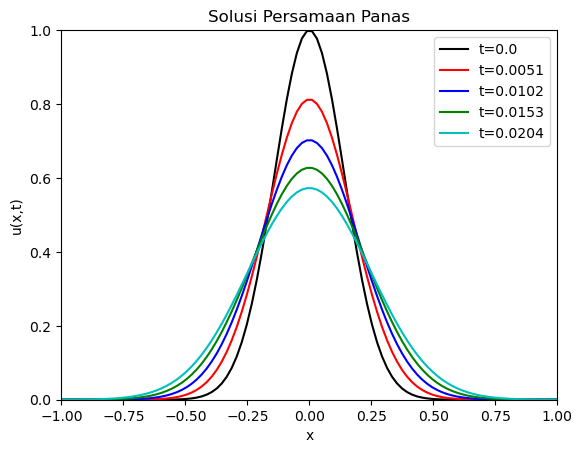

In [4]:
# Menghitung solusi Persamaan Panas menggunakan metode Forward Euler 
# dan pendekatan turunan kedua dengan beda hingga pusat orde dua

# Diskretisasi ruang
m = 100
x = numpy.linspace(-1.0, 1.0, m)
delta_x = 2.0 / (m - 1.0)

# Diskretisasi waktu
delta_t = 0.5 * delta_x**2
N = 101
t = numpy.arange(0.0, N * delta_t, delta_t)

# Array solusi
U = numpy.empty((N + 1, m))

# Kondisi awal dan kondisi batas
U[0, :] = numpy.exp(-x**2 / 0.2**2)
g_0 = lambda t: 0.0
g_1 = lambda t: 0.0

# Perulangan langkah waktu
for n in range(len(t)):
    for i in range(1,len(x) - 1):
        U[n+1, i] = U[n, i] + delta_t / delta_x**2 * (U[n, i-1] - 2.0 * U[n, i] + U[n, i+1])
    # Batas domain
    U[n+1, 0] = U[n, 0] + delta_t / delta_x**2 * (g_0(t[n]) - 2.0 * U[n, 0] + U[n, 1])
    U[n+1, -1] = U[n, -1] + delta_t / delta_x**2 * (U[n, -2] - 2.0 * U[n, -1] + g_1(t[n]))

# Menampilkan beberapa hasil solusi
colors = ['k', 'r', 'b', 'g', 'c']
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
for (i, n) in enumerate((0, 25, 50, 75, 100)):
    axes.plot(x, U[n, :], colors[i], label='t=%s' % numpy.round(t[n], 4))
    axes.set_xlabel("x")
    axes.set_ylabel("u(x,t)")
    axes.set_title("Solusi Persamaan Panas")
    axes.set_xlim([-1,1])
    axes.set_ylim([0.0, 1.0])
axes.legend()
plt.show()

Untuk metode $\textit{Crank--Nicholson}$, diketahui bahwa metode $\textit{trapezoidal}$ bersifat $\textit{absolutely stable}$, sehingga kita dapat memilih nilai $\Delta t$ berapa pun. Namun, jika $\Delta t$ terlalu besar maka akurasi solusi dapat berkurang, sehingga perlu kehati-hatian dalam menentukan nilai $\Delta t$ saat menggunakan metode ini. Secara umum, kita dapat memilih $\Delta t = \mathcal{O}(\Delta x)$ untuk memperoleh solusi yang cukup baik.

delta_x = 0.020202020202020204
delta_t = 0.010101010101010102


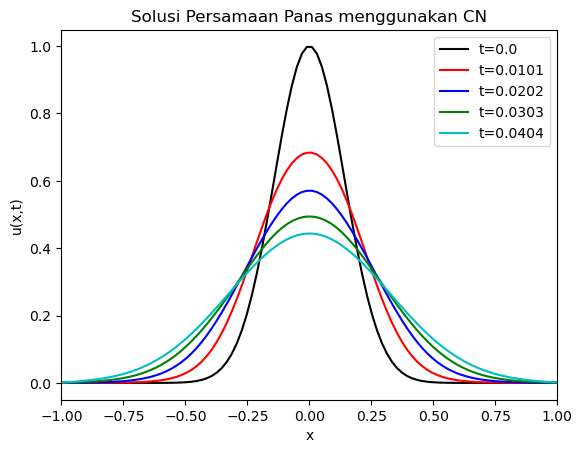

In [5]:
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

# Menghitung solusi Persamaan Panas menggunakan metode Crank-Nicholson
# Diskretisasi ruang
m = 100
x = numpy.linspace(-1.0, 1.0, m)
delta_x = 2.0 / (m - 1.0)
print("delta_x = %s" % delta_x)

# Diskretisasi waktu - Pilih Δt berdasarkan batasan akurasi
C = 0.5
delta_t = C * delta_x
t = numpy.arange(0.0, 1.0, delta_t)
N = len(t)
print("delta_t = %s" % delta_t)

# Array solusi
U = numpy.empty((N + 1, m))

# Kondisi awal dan kondisi batas
U[0, :] = numpy.exp(-x**2 / 0.2**2)
g_0 = lambda t: 0.0
g_1 = lambda t: 0.0

# Membuat matriks penyelesaian
r = numpy.ones(m) * delta_t / (2.0 * delta_x**2)
A = sparse.spdiags([-r, 1.0 + 2.0 * r, -r], [-1, 0, 1], m, m).tocsr()

# Membuat matriks untuk perhitungan ruas kanan
# Perhatikan bahwa kita juga harus menangani kondisi batas pada loop utama
# karena kondisi batas dapat bergantung pada waktu
B = sparse.spdiags([r, 1.0 - 2.0 * r, r], [-1, 0, 1],  m, m).tocsr()

# Loop langkah waktu
for n in range(len(t)-1):
    # Menyusun ruas kanan
    b = B.dot(U[n, :])
    b[0] += delta_t / (2.0 * delta_x**2) * (g_0(t[n]) + g_0(t[n+1]))
    b[-1] += delta_t / (2.0 * delta_x**2) * (g_1(t[n]) + g_1(t[n+1]))
    
    # Menyelesaikan sistem persamaan
    U[n+1, :] = linalg.spsolve(A, b)

# Menampilkan beberapa solusi
colors = ['k', 'r', 'b', 'g', 'c']
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
for (i, n) in enumerate((0, 1, 2, 3, 4)):
    axes.plot(x, U[n, :], colors[i], label='t=%s' % numpy.round(t[n], 4))
    axes.set_xlabel("x")
    axes.set_ylabel("u(x,t)")
    axes.set_title("Solusi Persamaan Panas menggunakan CN")
    axes.set_xlim([-1,1])
axes.legend()
plt.show()

Hal ini menimbulkan pertanyaan mengenai bagaimana kita mempertimbangkan stabilitas ketika terdapat dua parameter yang berubah, yaitu $\Delta t$ dan $\Delta x$. Metode garis (*method of lines*) memisahkan permasalahan menjadi analisis bagian spasial dan temporal, yang sangat membantu (dan pendekatan ini akan terus kita gunakan). 

Namun demikian, pendekatan ini tidak sepenuhnya memberikan gambaran lengkap karena beberapa suku dari masing-masing pendekatan dapat saling meniadakan. Hal ini dapat terjadi ketika deret Taylor dan substitusi yang sesuai dari persamaan diferensial parsial (PDE) beserta turunannya saling menghilangkan satu sama lain.

### **Kekakuan (Stiffness) dan Persamaan Panas**

Ingat bahwa nilai eigen terbesar dari sistem diskret untuk $u_{xx} = f(x)$ berperilaku sebagai $\lambda_m = -\frac{4}{\Delta x^2}$ sedangkan yang terkecil adalah $\lambda_1 \approx -\pi^2$. Rasio kekakuan kemudian kira-kira
$$
\frac{\lambda_m}{\lambda_1} \approx \frac{4\pi^2}{\Delta x^2} \rightarrow \infty 
\quad \text{ketika} \quad \Delta x \rightarrow 0.
$$

Kekakuan (stiffness) ini disebabkan oleh sifat dari persamaan panas. Pengaruh persamaan ini berlangsung cepat untuk data dengan frekuensi tinggi dan lambat untuk data dengan frekuensi rendah. Hal ini dapat dilihat melalui analisis Fourier dari persamaan asli. Jika diasumsikan $g_0(t) = g_1(t) = 0$, maka solusi dari persamaan panas dapat dituliskan sebagai

$$
u(x,t) = \sum_{j=1}^{\infty} \hat{u}_j(t)\sin(j\pi x).
$$

Untuk mencari koefisien $\hat{u}_j(t)$, deret ini disubstitusikan ke dalam persamaan diferensial parsial (PDE) sehingga diperoleh
$$
\hat{u}_j'(t) = -j^2\pi^2 \hat{u}_j(t).
$$

Hal ini menghasilkan solusi dalam bentuk
$$
\hat{u}_j(t) = \hat{u}_j(0)e^{-j^2\pi^2 t}.
$$

Dari persamaan tersebut dapat dilihat bahwa data awal $\hat{u}_j(0)$ diuraikan menjadi komponen-komponen Fourier, di mana komponen dengan frekuensi lebih tinggi akan meredam jauh lebih cepat terhadap waktu dibandingkan komponen dengan frekuensi rendah.

Jika kita ingin memperoleh solusi dari persamaan panas untuk periode waktu yang panjang, misalnya untuk mempelajari keadaan tunak (steady-state), maka akan muncul masalah jika menggunakan diskretisasi waktu yang tidak memungkinkan penggunaan langkah waktu yang besar. 

Jika kita memilih metode diskretisasi yang tidak memiliki batasan stabilitas, maka yang perlu diperhatikan hanyalah tingkat akurasi metode tersebut. Sebagai contoh, jika kita menginginkan orde akurasi yang sama pada ruang dan waktu, kita dapat memilih $\Delta t \approx \Delta x$ Namun, pemilihan ini hanya dapat dilakukan apabila metode yang digunakan tidak memiliki keterbatasan stabilitas.

### **Konvergensi**

Sekarang kita membahas bagaimana pendekatan numerik $U_i^n$ pada titik $(x_i,t_n)$ dapat mendekati solusi sebenarnya $u(x_i,t_n)$. 

Perhatikan bahwa pada kasus ini kita memiliki dua parameter yang harus diperkecil, yaitu $\Delta t$ dan $\Delta x$. Kedua parameter tersebut harus menuju nol agar solusi numerik semakin mendekati solusi sebenarnya.

Hal ini pada dasarnya membentuk suatu urutan grid dalam ruang dan waktu yang dapat dinyatakan sebagai $(\Delta t_1, \Delta x_1), \; (\Delta t_2, \Delta x_2), \; \ldots$

Ternyata hubungan antara $\Delta t$ dan $\Delta x$ yang harus dipenuhi agar konvergensi terjadi sama dengan hasil kondisi stabilitas yang telah diperoleh sebelumnya. Oleh karena itu, sering kali kriteria konvergensi dipandang sebagai suatu aturan yang menghubungkan $\Delta t$ dan $\Delta x$, sehingga pada dasarnya kita hanya memiliki satu parameter yang perlu divariasikan.

Sambil membahas hal ini, mari kita generalisasikan ke dalam suatu kelas metode yang dapat dituliskan sebagai

$$
    U^{n+1} = B(\Delta t) U^n + b^n(\Delta t).
$$

dengan $B(\Delta t) \in \mathbb R^{m\times m}$ pada grid yang memiliki $\Delta x = 1 / (m + 1)$, dan $b^n(\Delta t) \in \mathbb R^m$.  

Di sini, kita membiarkan $\Delta t \rightarrow 0$, lalu menentukan nilai $\Delta x$ berdasarkan hubungan kestabilan atau ketelitian antara $\Delta t$ dan $\Delta x$.

Sebagai contoh, metode Euler maju yang telah dibahas dapat dituliskan sebagai

$$
    U^{n+1} = U^n + \Delta t A U^n \Rightarrow     B(\Delta t) = I + \Delta t A, \quad b^n(\Delta t) = 0
$$

di mana $A$ adalah diskretisasi tridiagonal yang muncul dari pendekatan beda hingga pusat orde dua.

Cobalah untuk menentukan bagaimana bentuk metode Crank-Nicholson, khususnya pada bagian $B(\Delta t)$.

Untuk metode Crank-Nicholson, diperoleh

$$
    B(\Delta t) = \left( I - \frac{\Delta t}{2} A \right )^{-1} \left( I + \frac{\Delta t}{2} A \right ).
$$

Sekarang kita beralih ke definisi formal mengenai konvergensi. Namun, untuk melakukannya kita memerlukan beberapa definisi tambahan, yaitu kestabilan dan konsistensi, agar dapat menunjukkan konvergensi.

Suatu metode linear berbentuk

$$
    U^{n+1} = B(\Delta t) U^n + b^n(\Delta t)
$$

disebut *stabil Lax-Richtmyer* jika, untuk setiap waktu $T$, terdapat konstanta $C_T > 0$ sehingga

$$
    ||B(\Delta t)^n|| \leq C_T
$$

untuk semua $\Delta t > 0$ dan $n \in \mathbb Z$ yang memenuhi $\Delta t n \leq T$.

*Teorema Ekuivalensi Lax* — Suatu metode linear konsisten dengan bentuk yang sama akan konvergen jika dan hanya jika metode tersebut stabil menurut Lax-Richtmyer.

Ide dasar dari hasil-hasil ini mirip dengan yang telah kita lihat saat membahas metode Euler. Jika bentuk linear umum diterapkan pada solusi sebenarnya, maka diperoleh

$$
    u(x, t_{n+1}) = B u(x, t_{n}) + b(t_n) + \Delta t \tau(x, t_n)
$$

di mana $u$ adalah vektor yang dievaluasi pada titik-titik spasial yang didefinisikan oleh $x \in \mathbb R^m$.  

Dengan mengurangkan persamaan ini dari skema linear asal, diperoleh

$$
    U^{n+1} - u(x, t_{n+1}) = B (U^{n} - u(x, t_{n})) - \Delta t \tau^n
$$

atau dapat ditulis sebagai

$$
    E^{n+1} = B E^{n} - \Delta t \tau^n.
$$

Setelah $N$ langkah waktu, maka diperoleh

$$
    E^N = B^N E^0 - \Delta t \sum^N_{n=1} B^{N - n} \tau^{n-1}.
$$

Dengan menggunakan norma yang sesuai, kita mendapatkan hubungan

$$
    ||E^N|| \leq ||B^N || ||E^0|| + \Delta t \sum^N_{n=1} ||B^{N - n}||  ||\tau^{n-1}||.
$$

Jika metode tersebut stabil menurut Lax-Richtmyer, maka untuk $N \Delta t \leq T$ berlaku

$$
    ||E^N|| \leq C_T ||E^0|| + T C_T \max_{1 \leq n \leq N} ||\tau^{n-1}||.
$$

Saat $\Delta t \rightarrow 0$, galat ini akan menuju $0$ selama metode tersebut konsisten ($\tau \rightarrow 0$) dan $E^0 \rightarrow 0$.

Agar lebih jelas, perhatikan kembali diskretisasi Euler maju. Pada norma 2, kita mengetahui bahwa

$$
    ||B(\Delta t)||_2 \leq 1
$$

dengan syarat $\Delta t / \Delta x^2 \leq 1 / 2$. Hal ini menunjukkan bahwa metode tersebut stabil menurut Lax-Richtmyer, sehingga metode ini konvergen.

Demikian pula untuk metode Crank-Nicholson, metode ini stabil menurut Lax-Richtmyer untuk sembarang pilihan $\Delta t$ dan $\Delta x$, karena nilai eigen dari $B(\Delta t)$ pada kasus ini adalah

$$
    \lambda = \frac{1 + \Delta t \lambda_p / 2}{1 - \Delta t \lambda_p / 2}.
$$

Perlu dicatat terakhir bahwa untuk metode-metode yang telah kita bahas sejauh ini, kita memiliki

$$
    ||B|| \leq 1
$$

yang disebut sebagai *stabilitas kuat* (*strong stability*).  

Namun, pada kenyataannya stabilitas Lax-Richtmyer lebih lemah daripada kondisi ini, dan tetap terpenuhi jika dapat ditemukan suatu $\alpha$ sehingga

$$
    ||B(\Delta t)|| \leq 1 + \alpha \Delta t.
$$

## **Analisis Von Neumann**

Sebagai alternatif dari analisis *method of lines* di atas, kita dapat menggunakan analisis Fourier untuk memahami bagaimana berbagai mode numerik dari suatu metode berkembang terhadap waktu, yang disebut sebagai *analisis von Neumann*.  

Pendekatan ini umumnya membatasi analisis hanya pada PDE linear dengan koefisien konstan, tetapi merupakan cara yang sangat kuat untuk menganalisis sifat kestabilan suatu metode dengan lebih mudah.  

Dalam analisis ini, PDE juga biasanya dipelajari sebagai *masalah Cauchy* agar persoalan yang berkaitan dengan syarat batas dapat dihilangkan.

Dengan menggunakan bentuk eksponensial dari transformasi Fourier, kita mengetahui bahwa secara umum fungsi eigen dari turunan spasial akan berubah menjadi hubungan aljabar, karena

$$
    \partial_x e^{i \xi x} = i \xi e^{i \xi x}.
$$

Demikian pula, kita mengetahui bahwa versi terdiskretisasi dari fungsi eigen ini adalah

$$
    W_j = e^{i j \Delta x \xi}
$$

untuk operator beda hingga yang bersifat invarian terhadap translasi.

Sebagai contoh, mari kita terapkan fungsi grid ini pada pendekatan beda hingga pusat orde dua untuk turunan pertama:

$$\begin{aligned}
    D_0 W_j &= \frac{e^{i (j+1) \Delta x \xi} - e^{i (j-1) \Delta x \xi}}{2 \Delta x} \\ 
    &= e^{i j \Delta x \xi} \frac{e^{i \Delta x \xi} - e^{-i \Delta x \xi}}{2 \Delta x} \\
    &=\frac{i}{\Delta x} \sin(\Delta x \xi) e^{i j \Delta x \xi} \\
    &=\frac{i}{\Delta x} \sin(\Delta x \xi) W_j.
\end{aligned}$$

Dari hasil ini, kita mengetahui bahwa $W_j$ merupakan fungsi eigen dari $D_0$ dengan nilai eigen yang bersesuaian sebesar

$$
\frac{i}{\Delta x} \sin(\Delta x \xi).
$$

Satu hal penting mengenai nilai eigen ini dapat dilihat dengan mengembangkannya ke dalam deret Taylor, sehingga diperoleh

$$
    \frac{i}{\Delta x} \sin(\Delta x \xi) = \frac{i}{\Delta x} \left( \Delta x \xi - \frac{1}{6} \Delta x^3 \xi^3 + \cdots \right ) = i \xi - \frac{i}{6} \Delta x^2 \xi^2 + \cdots
$$

yang menunjukkan bahwa saat $\Delta x \rightarrow 0$, nilai eigen diskret tersebut sesuai dengan nilai eigen kontinu.

Sekarang misalkan kita mempunyai fungsi grid lain $V_j$ yang didefinisikan pada titik $x_j = j \Delta x$ untuk $j = 0, \pm 1, \pm 2, \ldots$. Misalkan $V_j$ merupakan fungsi $\ell_2$, dalam arti

$$
    ||U||_2 = \left( \Delta x \sum^\infty_{j=-\infty} |U_j|^2 \right )^{1/2} < \infty.
$$

Jika syarat ini terpenuhi, maka kita dapat mengambil transformasi Fourier dari fungsi grid tersebut sehingga

$$
    V_j = \frac{1}{\sqrt{2 \pi}} \int^{\pi/\Delta x}_{-\pi / \Delta x} \hat{V~}(\xi) e^{ij \Delta x \xi} d\xi
$$

dengan koefisien Fourier

$$
    \hat{V~}(\xi) = \frac{\Delta x}{\sqrt{2 \pi}} \sum^\infty_{j=-\infty} V_j e^{-i j \Delta x \xi}.
$$

Berdasarkan relasi Parseval, kita juga mengetahui bahwa

$$
||\hat{V~}||_2 = ||V||_2.
$$

Kembali ke tujuan utama kita, yaitu menunjukkan kestabilan, kita mengetahui bahwa kita perlu membuktikan bahwa

$$
    \| U^{n+1} \|_2 \leq (1 + \alpha \Delta t) \|U^n\|_2.
$$

Dengan menggunakan relasi Parseval, kita memperoleh

$$
    \|\hat{U~}^{n+1}\|_2 \leq (1 + \alpha \Delta t) \|\hat{U~}^n\|_2.
$$

Karena operator spasial diskret dapat diubah melalui transformasi Fourier, maka hasil ini bisa diperoleh lebih mudah dibandingkan menggunakan bentuk aslinya. Sebagai contoh,

$$
    \hat{U~}^{n+1}(\xi) = g(\xi) \hat{U~}^n(\xi)
$$

di mana faktor $g(\xi)$ disebut sebagai *faktor amplifikasi* (*amplification factor*) untuk bilangan gelombang tertentu $\xi$.

Jika kita dapat menunjukkan bahwa

$$
    |g(\xi)| \leq 1 + \alpha \Delta t
$$

dengan $\alpha$ tidak bergantung pada $\xi$, maka akan diperoleh

$$
    |\hat{U~}^{n+1}| \leq (1 + \alpha \Delta t) |\hat{U~}^n|
$$

untuk semua $\xi$, sehingga

$$
    \|\hat{U~}^{n+1}\|_2 \leq (1 + \alpha \Delta t) \|\hat{U~}^n\|_2.
$$

### Contoh - Euler Maju

Mari kita tinjau bagaimana diskretisasi awal kita untuk persamaan panas dituliskan dalam kerangka yang baru saja dikembangkan. Metode tersebut adalah

$$
    U_j^{n+1} = U^n_j + \frac{\Delta t}{\Delta x^2} (U^n_{j+1} - 2 U^n_j + U^n_{j-1} ).
$$

Cobalah turunkan bentuk $g(\xi)$ dan selanjutnya tentukan kriteria kestabilannya.

Dengan mensubstitusikan $U^n_j = e^{i j \Delta x \xi}$, diperoleh

$$\begin{aligned}
    U_j^{n+1} &= U^n_j + \frac{\Delta t}{\Delta x^2} (e^{i \Delta x \xi} U^n_j -2 U^n_j + e^{-i \Delta x \xi} U^n_j) \\
    &= \left(1 + \frac{\Delta t}{\Delta x^2} \left(e^{i \Delta x \xi} -2+ e^{-i \Delta x \xi} \right) \right ) U^n_j \\
    &= g(\xi) U^n_j.
\end{aligned}$$

Dengan menuliskan ulang faktor amplifikasi, kita peroleh

$$
    g(\xi) = 1 + 2 \frac{\Delta t}{\Delta x^2} (\cos(\xi \Delta x) - 1)
$$

Karena untuk semua $\xi$ berlaku

$$
-1 \leq \cos (\xi \Delta x) \leq 1,
$$

maka $g(\xi)$ dapat dibatasi sebagai

$$
    1 -4 \frac{\Delta t}{\Delta x^2} \leq g(\xi) \leq 1 \quad \forall \xi.
$$

Oleh karena itu, metode ini stabil jika

$$
    \frac{4 \Delta t}{\Delta x^2} \leq 2
$$

seperti yang telah kita peroleh sebelumnya.

### Contoh - Crank-Nicholson

Kembali, dengan mensubstitusikan fungsi $U^n_j = e^{ij\Delta x \xi}$ ke dalam metode

$$
    U^{n+1}_j = U^n_j + \frac{\Delta t}{2 \Delta x^2} (U^n_{j-1} - 2 U^n_{j} + U^n_{j+1} + U^{n+1}_{j-1} - 2 U^{n+1}_{j} + U^{n+1}_{j+1})
$$

diperoleh

$$
    U^{n+1}_j = U^n_j + \frac{\Delta t}{2 \Delta x^2} \left[ \left(e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right) U^n_{j}+ \left(e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right) U^{n+1}_{j} \right ]
$$

sehingga

$$
    g(\xi) = 1 + \frac{\Delta t}{2 \Delta x^2} \left(  e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right ) (1 + g(\xi))
$$

dengan memperhatikan bahwa $U^{n+1}_j = g(\xi) U^n_j$ sesuai asumsi.

Dengan menyelesaikan persamaan tersebut terhadap faktor amplifikasi, diperoleh

$$
    g = \frac{1+ \frac{z}{2}}{1 - \frac{z}{2}}
$$

dengan

$$
    z = \frac{\Delta t}{\Delta x^2} \left (e^{i \Delta x \xi} - 2 + e^{-i\Delta x \xi} \right ) = \frac{2 \Delta t}{\Delta x^2} (\cos(\xi \Delta x) - 1).
$$

Karena $z \leq 0$ untuk semua $\xi$, maka dapat disimpulkan bahwa metode ini stabil tanpa bergantung pada pilihan $\Delta t$ dan $\Delta x$.

## **Dimensi Spasial Ganda**

Tentu saja, kita dapat melanjutkan analisis dengan mempertimbangkan lebih dari satu dimensi spasial. Untuk persamaan panas dalam 2 dimensi spasial, diperoleh

$$
    u_t = u_{xx} + u_{yy}
$$

dengan kondisi awal dua dimensi dan kondisi batas yang sesuai.

Dengan menggunakan bentuk diskret dari operator Laplace yang telah diturunkan sebelumnya, kita dapat menuliskan, misalnya, metode Crank-Nicholson untuk PDE ini sebagai

$$
    U^{n+1}_{ij} = U^n_{ij} + \frac{\Delta t}{2} \left (\nabla^2_{\Delta x} U^n_{ij} + \nabla^2_{\Delta x} U^{n+1}_{ij} \right)
$$

dengan asumsi bahwa $\Delta x = \Delta y$.  

Secara umum, bentuk ini menghasilkan suatu sistem persamaan yang harus diselesaikan dengan struktur

$$
    A U^{n+1}_{ij} = b.
$$

Untuk membentuk sistem persamaan tersebut, persamaan di atas ditulis ulang menjadi

$$
    \left(I - \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n+1}_{ij} = \left(I + \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n}_{ij}
$$

sehingga diperoleh

$$
    A = I - \frac{\Delta t}{2} \nabla^2_{\Delta x}
$$

dan

$$
    b = \left(I + \frac{\Delta t}{2} \nabla^2_{\Delta x} \right ) U^{n}_{ij}.
$$

Selanjutnya, kita dapat menggunakan metode penyelesaian sistem linear besar dan jarang (*large, sparse linear system*) pada setiap langkah waktu untuk mengembangkan solusi sistem tersebut.

Dalam hal kestabilan metode ini, kita dapat menghitung nilai eigen dari $A$ sehingga diperoleh

$$
    \lambda_{p,q} = 1 - \frac{\Delta t}{\Delta x^2} ((\cos(p \pi \Delta x) -1) + (\cos(q \pi \Delta x) - 1))
$$

dengan menggunakan pengetahuan kita tentang nilai eigen dari $\nabla^2_{\Delta x}$.

Dengan hasil ini, kita mengetahui banyak hal mengenai tingkat kesulitan penyelesaian masalah tersebut.  

Sebagai contoh, kita mengetahui bahwa nilai eigen terbesar (dalam magnitudo) akan berorde

$$
\mathcal{O}\left(\frac{\Delta t}{\Delta x^2}\right),
$$

sedangkan nilai eigen yang paling dekat ke titik asal akan berorde

$$
\mathcal{O}(\Delta t) + 1.
$$

Akibatnya, bilangan kondisi (*condition number*) untuk matriks $A$ berada pada orde

$$
\mathcal{O}\left(\frac{\Delta t}{\Delta x^2}\right).
$$

Hal ini sebenarnya menguntungkan, karena sekarang $\Delta t$ juga memengaruhi bilangan kondisi matriks, sedangkan sebelumnya saat membahas masalah ini nilainya hanya berorde

$$
\mathcal{O}\left(\frac{1}{\Delta x^2}\right).
$$

Penerapan metode iteratif yang telah kita bahas sebelumnya pada tahap ini seharusnya bekerja dengan baik.  

Perlu dicatat bahwa sebagai tebakan awal (*initial guess*), kita dapat menggunakan solusi pada langkah waktu sebelumnya, atau menggunakan satu langkah waktu eksplisit untuk mengekstrapolasi tebakan solusi.

### Pemisahan Dimensi (*Dimensional Splitting*)

Pendekatan lain untuk diskretisasi pada banyak dimensi spasial adalah memecah masalah menjadi beberapa masalah satu dimensi spasial. Dengan kata lain, kita menyelesaikan proses dua langkah sebagai berikut:

$$\begin{aligned}
    U^\ast_{ij} = U^n_{ij} + \frac{\Delta t}{2} (D^2_x U^n_{ij} + D^2_x U^\ast_{ij}) \\
    U^{n+1}_{ij} = U^\ast_{ij} + \frac{\Delta t}{2} (D^2_y U^\ast_{ij} + D^2_y U^{n+1}_{ij}).
\end{aligned}$$

Secara efektif, cara ini memungkinkan besaran $U$ mengalami difusi terlebih dahulu pada arah $x$, kemudian secara terpisah pada arah $y$.

Apakah metode ini benar-benar bekerja?

Jika syarat batas diabaikan, metode ini bekerja sama baiknya dengan pendekatan terkopel sebelumnya saat $\Delta t \rightarrow 0$.

Hal ini berasal dari fakta bahwa operator $\partial_{xx}$ dan $\partial_{yy}$ saling komutatif (*commute*), artinya urutan penerapan kedua operator tersebut tidak memengaruhi hasil. Fakta ini akan kita bahas kembali saat mempelajari pendekatan pemisahan yang lebih umum.

Bagaimana dengan kondisi batas?

Karena proses dua langkah yang telah diperkenalkan, kita sekarang memerlukan satu himpunan kondisi batas tambahan untuk $U^\ast$ yang harus ditentukan.

Secara umum, kondisi batas yang digunakan bergantung pada jenis masalah dan bisa tidak sederhana untuk ditentukan. Sebagai contoh, proses di atas dapat dipandang sebagai mengambil setengah langkah waktu pada satu arah, sehingga nilai batas seharusnya dievaluasi pada waktu

$$
t_n + \frac{\Delta t}{2}.
$$

Pendekatan pemisahan lain yang sebagian mengatasi persoalan kondisi batas adalah metode *Alternating Direction Implicit* (ADI), yang didefinisikan sebagai

$$\begin{aligned}
    U^\ast_{ij} = U^n_{ij} + \frac{\Delta t}{2} (D^2_y U^n_{ij} + D^2_x U^\ast_{ij}) \\
    U^{n+1}_{ij} = U^\ast_{ij} + \frac{\Delta t}{2} (D^2_x U^\ast_{ij} + D^2_y U^{n+1}_{ij})
\end{aligned}$$

Metode ini lebih jelas menunjukkan gagasan bahwa kita sedang memprediksi solusi pada masing-masing arah pada waktu

$$
t_n + \frac{\Delta t}{2},
$$

sehingga penggunaan waktu tersebut sebagai kondisi batas menjadi konsisten.

## Strategi Diskretisasi Alternatif

Tentu saja, terdapat berbagai alternatif yang dapat digunakan untuk menyelesaikan PDE parabolik.  

Di sini kita berfokus pada penggunaan metode Euler maju atau aturan trapesium untuk diskretisasi waktu, serta diskretisasi spasial pusat orde dua. Namun, masing-masing pendekatan tersebut dapat diganti dengan metode lain, yang pada beberapa kasus mungkin lebih menguntungkan untuk masalah tertentu.